# Assignment: Trees
Do three questions.

**Q1.** Please answer the following questions in your own words.

1. How are trees constructed?

2. How do trees handle non-linear relationships between variables? Compare this to linear models. 

3. Why is the Gini a good loss function for categorical target variables? 

4. Why do trees tend to overfit, and how can this tendency be constrained? 

5. True or false, and explain: Trees only really perform well in situations with lots of categorical variables as features/covariates. 

6. Why don't most versions of classification/regression tree concept allow for more than two branches after a split?

7. What are some heuristic ways you can examine a tree and decide whether it is probably over- or under-fitting?

1. Trees are built by splitting the data into smaller and smaller groups. You start with the whole dataset and choose the feature that best separates the target like class or value. Then you split the data into two parts based on that feature. This process repeats for each group and keeps splitting until you hit a stopping point whcih happens when the tree is getting too deep or not having enough data left to split. Each split tries to make the groups as "pure" as possible, meaning the target values in each group are similar.

2. Trees are good at handling non-linear stuff because they break the data into smaller chunks and make simple rules for each chunk. Even if the real pattern is curvy or complicated, the tree follows it using a bunch of straight splits kind of like building a staircase to follow a curvy hill. On the other hand, linear models can only draw straight lines so they dont do well with curves unless you change. 

3. Gini impurity tells us how mixed up the classes are in a group. If the Gini is low, that means most of the data in the group is from the same class  which is a good thing. Trees use Gini to decide where to split because it helps make groups that are more pure which means better predictions. 

4. Trees overfit when they split too much and end up fitting the noise in the data instead of the real patterns. To stop this, we can limit how deep the tree goes, make sure each leaf has enough data, cut back parts of the tree (pruning), or use methods like random forests to smooth things out.

5. Trees can handle both numbers and categories.  For numbers, they just ask simple questions like “is age > 45?”. For categories, they don’t need to change them into numbers as they can just work with them as they are. 

6. Most trees only split into two parts at a time because it’s simpler, easier to manage, and helps the tree make more detailed decisions step by step. It also saves time since two-way splits are faster to calculate than splitting into many parts.

7. We can tell if a tree is overfitting when its super deep and has a lot of tiny branches and seems to do really well on the training data but not so great on new or test data. This usually means that its memorizing the training set instead of learning real patterns. On the other hand, if the tree is small or shallow and it does poorly on both training and test data then its underfitting meaning its too simple to learn whats going on int he data. Another thing we can look out for is if some leaves have only a few samples which can be a sign of the tree memorizing those points. Or if a bunch of leaves are all giving same prediction, the tree might not be doing much thinking at all. 

**Q2.** This is a case study on regression and classification trees.

1. Load `./data/cars_hw.csv`. How many observations and features/covariates/variables? What are the available variables? Take a look at the first few rows of data.

2. For the categorical variables `Make`, `Color`, `Body_type`, `No_of_Owners`, `Fuel_Type`, `Transmission`, and `Transmission_Type`, create dummy/one-hot-encoded representations. For numeric variables, we'll use `Mileage_Run`, `Make_Year`, and `Seating_Capacity`. Our target variable will be `Price`. Make a train-test split of your data.

3. From `sklearn.tree`, import the `DecisionTreeRegressor` and `plot_tree`. Use a train-test split to iterate over possible values for `min_samples_leaf`, computing the $R^2$ for each value between 1 and 25. What choice achieves the highest $R^2$ on the test data?

4. For the optimal `min_samples_leaf` from 3, regress price on the rest of the features/covariates using the training data. What is your $R^2$ and RMSE on the test set? Plot the dendrogram. Plot the residuals. Is the density of residuals symmetric and centered around 0?

4. Run a linear regression of price on the same variables. Which model -- regression tree or linear regression -- performs better on the test set? Why?

5. Predict prices using both your tree and your linear model, and make a scatter plot of their values. Describe what you see. 

In [1]:
#loading dataset
import pandas as pd
df = pd.read_csv('./data/cars_hw.csv')
print("Shape:", df.shape)
print("Columns:", df.columns.tolist())
df.head()

Shape: (976, 12)
Columns: ['Unnamed: 0', 'Make', 'Make_Year', 'Color', 'Body_Type', 'Mileage_Run', 'No_of_Owners', 'Seating_Capacity', 'Fuel_Type', 'Transmission', 'Transmission_Type', 'Price']


,Unnamed: 0,Make,Make_Year,Color,Body_Type,Mileage_Run,No_of_Owners,Seating_Capacity,Fuel_Type,Transmission,Transmission_Type,Price
0,1,Volkswagen,2017,silver,sedan,44611,1st,5,diesel,7-Speed,Automatic,657000
1,2,Hyundai,2016,red,crossover,20305,1st,5,petrol,5-Speed,Manual,682000
2,3,Honda,2019,white,suv,29540,2nd,5,petrol,5-Speed,Manual,793000
3,4,Renault,2017,bronze,hatchback,35680,1st,5,petrol,5-Speed,Manual,414000
4,5,Hyundai,2017,orange,hatchback,25126,1st,5,petrol,5-Speed,Manual,515000


In [4]:
#2
from sklearn.model_selection import train_test_split
import pandas as pd

categorical_vars = ['Make', 'Color', 'Body_Type', 'No_of_Owners', 'Fuel_Type', 'Transmission', 'Transmission_Type']
numeric_vars = ['Mileage_Run', 'Make_Year', 'Seating_Capacity']
target = 'Price'
df_encoded = pd.get_dummies(df[categorical_vars + numeric_vars + [target]], drop_first=True)

X = df_encoded.drop(columns=target)
y = df_encoded[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
#3
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score

r2_scores = []
for leaf_size in range(1, 26):
    dt = DecisionTreeRegressor(min_samples_leaf=leaf_size, random_state=42)
    dt.fit(X_train, y_train)
    y_pred = dt.predict(X_test)
    r2 = r2_score(y_test, y_pred)
    r2_scores.append((leaf_size, r2))

best_leaf = max(r2_scores, key=lambda x: x[1])
print(f"Best min_samples_leaf: {best_leaf[0]}, R^2: {best_leaf[1]:.4f}")

Best min_samples_leaf: 5, R^2: 0.8253


Tree R^2: 0.8253, RMSE: 141536.54


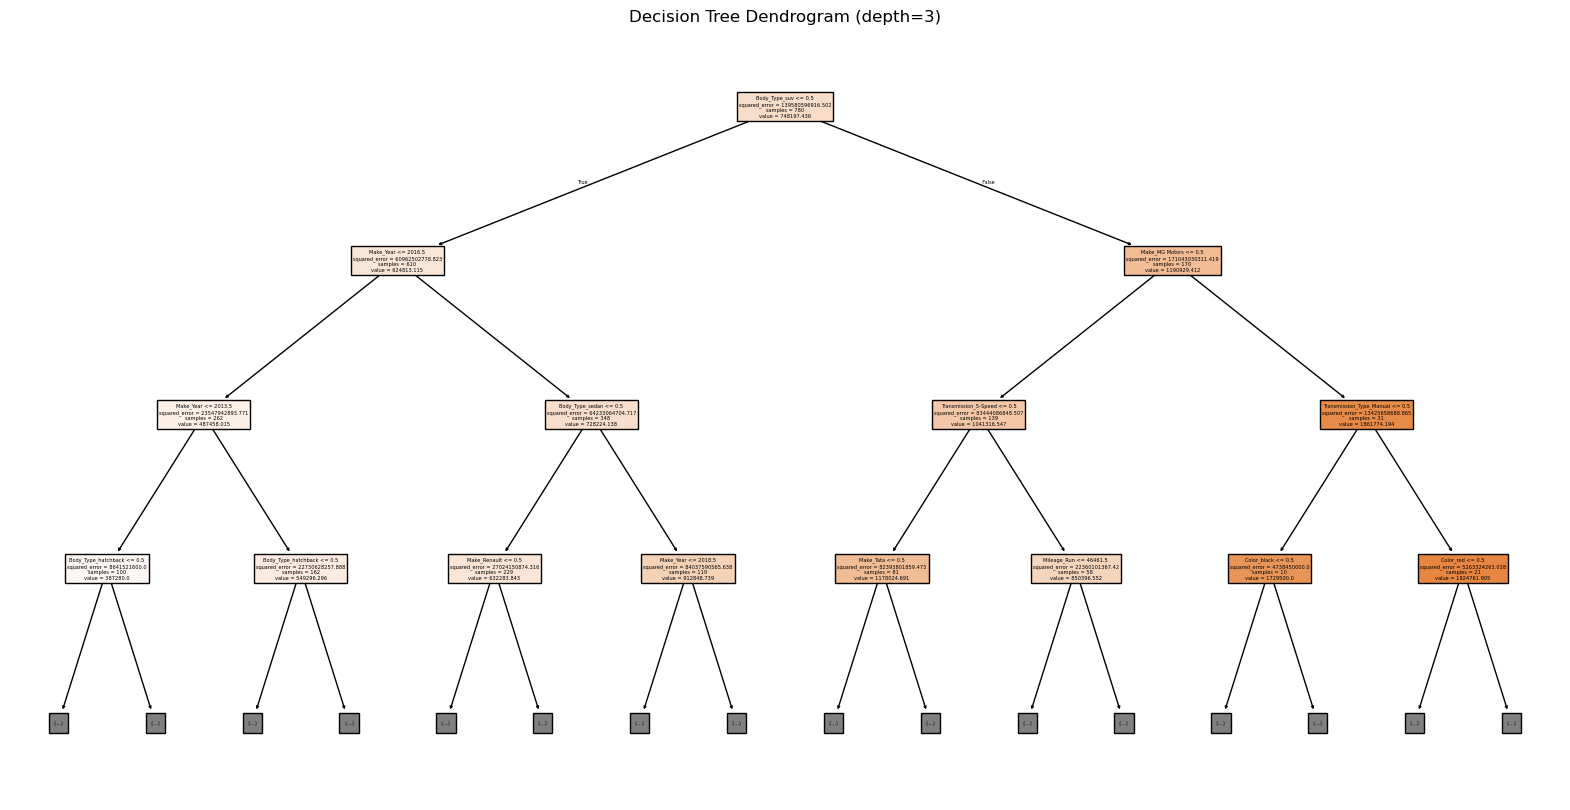

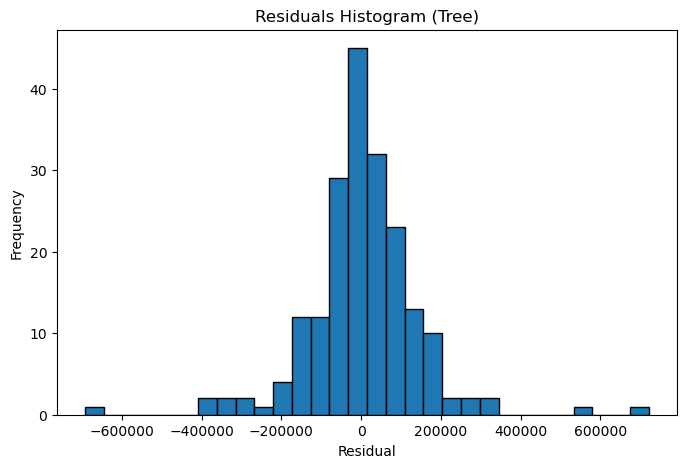

In [6]:
# 4
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

dt_best = DecisionTreeRegressor(min_samples_leaf=best_leaf[0], random_state=42)
dt_best.fit(X_train, y_train)

y_pred_tree = dt_best.predict(X_test)
r2_tree = r2_score(y_test, y_pred_tree)
rmse_tree = np.sqrt(mean_squared_error(y_test, y_pred_tree))

print(f"Tree R^2: {r2_tree:.4f}, RMSE: {rmse_tree:.2f}")

plt.figure(figsize=(20, 10))
plot_tree(dt_best, feature_names=X.columns, filled=True, max_depth=3)
plt.title("Decision Tree Dendrogram (depth=3)")
plt.show()

residuals = y_test - y_pred_tree
plt.figure(figsize=(8, 5))
plt.hist(residuals, bins=30, edgecolor='black')
plt.title("Residuals Histogram (Tree)")
plt.xlabel("Residual")
plt.ylabel("Frequency")
plt.show()

It is centered around 0 and is approximately symmetric. 

In [7]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
r2_lr = r2_score(y_test, y_pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(f"Linear Regression R^2: {r2_lr:.4f}, RMSE: {rmse_lr:.2f}")

Linear Regression R^2: 0.8203, RMSE: 143575.20


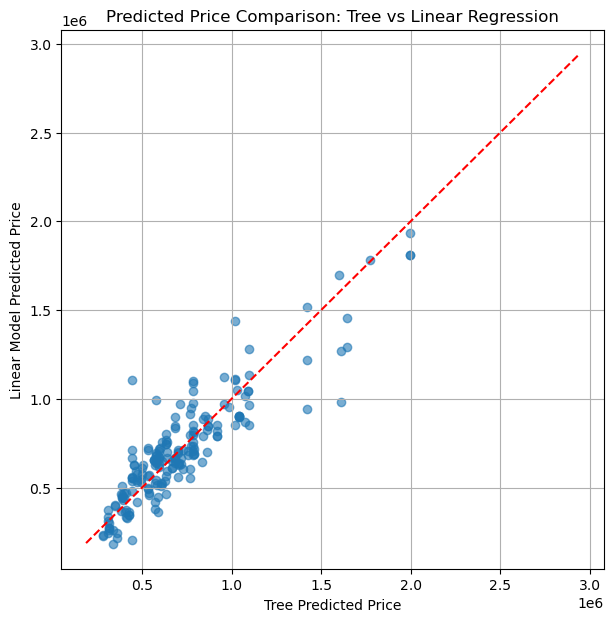

In [8]:
plt.figure(figsize=(7, 7))
plt.scatter(y_pred_tree, y_pred_lr, alpha=0.6)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--') 
plt.xlabel("Tree Predicted Price")
plt.ylabel("Linear Model Predicted Price")
plt.title("Predicted Price Comparison: Tree vs Linear Regression")
plt.grid(True)
plt.show()

**Q3.** This is a case study about classification and regression trees.

1. Load the `Breast Cancer METABRIC.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  We'll use a consistent set of feature/explanatory variables. For numeric variables, we'll include `Tumor Size`, `Lymph nodes examined positive`, `Age at Diagnosis`. For categorical variables, we'll include `Tumor Stage`, `Chemotherapy`, and `Cancer Type Detailed`. One-hot-encode the categorical variables and concatenate them with the numeric variables into a feature/covariate matrix, $X$.

3. Let's predict `Overall Survival Status` given the features/covariates $X$. There are 528 missing values, unfortunately: Either drop those rows from your data or add them as a category to predict. Constrain the minimum samples per leaf to 10. Print a dendrogram of the tree. Print a confusion matrix of the algorithm's performance. What is the accuracy? 

4. For your model in part three, compute three statistics:
    - The **true positive rate** or **sensitivity**:
        $$
        TPR = \dfrac{TP}{TP+FN}
        $$
    - The **true negative rate** or **specificity**:
        $$
        TNR = \dfrac{TN}{TN+FP}
        $$
    Does your model tend to perform better with respect to one of these metrics?

5. Let's predict `Overall Survival (Months)` given the features/covariates $X$. Use the train/test split to pick the optimal `min_samples_leaf` value that gives the highest $R^2$ on the test set (it's about 110). What is the $R^2$? Plot the test values against the predicted values. How do you feel about this model for clinical purposes?

**Q4.** This is a case study about trees using bond rating data. This is a dataset about bond ratings for different companies, alongside a bunch of business statistics and other data. Companies often have multiple reviews at different dates. We want to predict the bond rating (AAA, AA, A, BBB, BB, B, ..., C, D). Do business fundamentals predict the company's rating?

1. Load the `./data/corporate_ratings.csv` dataset. How many observations and variables does it contain? Print out the first few rows of data.

2.  Plot a histogram of the `ratings` variable. It turns out that the gradations of AAA/AA/A and BBB/BB/B and so on make it hard to get good results with trees. Collapse all AAA/AA/A ratings into just A, and similarly for B and C.

3. Use all of the variables **except** Rating, Date, Name, Symbol, and Rating Agency Name. To include Sector, make a dummy/one-hot-encoded representation and include it in your features/covariates. Collect the relevant variables into a data matrix $X$. 

4. Do a train/test split of the data and use a decision tree classifier to predict the bond rating. Including a min_samples_leaf constraint can raise the accuracy and speed up computation time. Print a confusion matrix and the accuracy of your model. How well do you predict the different bond ratings?

5. If you include the rating agency as a feature/covariate/predictor variable, do the results change? How do you interpret this?

In [9]:
#1
import pandas as pd
df = pd.read_csv('./data/corporate_ratings.csv')
print("Shape:", df.shape)
df.head()

Shape: (2029, 31)


,Rating,Name,Symbol,Rating Agency Name,Date,Sector,currentRatio,quickRatio,cashRatio,daysOfSalesOutstanding,...,effectiveTaxRate,freeCashFlowOperatingCashFlowRatio,freeCashFlowPerShare,cashPerShare,companyEquityMultiplier,ebitPerRevenue,enterpriseValueMultiple,operatingCashFlowPerShare,operatingCashFlowSalesRatio,payablesTurnover
0,A,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,11/27/2015,Consumer Durables,0.945894,0.426395,0.099690,44.203245,...,0.202716,0.437551,6.810673,9.809403,4.008012,0.049351,7.057088,15.565438,0.058638,3.906655
1,BBB,Whirlpool Corporation,WHR,Egan-Jones Ratings Company,2/13/2014,Consumer Durables,1.033559,0.498234,0.203120,38.991156,...,0.074155,0.541997,8.625473,17.402270,3.156783,0.048857,6.460618,15.914250,0.067239,4.002846
2,BBB,Whirlpool Corporation,WHR,Fitch Ratings,3/6/2015,Consumer Durables,0.963703,0.451505,0.122099,50.841385,...,0.214529,0.513185,9.693487,13.103448,4.094575,0.044334,10.491970,18.888889,0.074426,3.483510
3,BBB,Whirlpool Corporation,WHR,Fitch Ratings,6/15/2012,Consumer Durables,1.019851,0.510402,0.176116,41.161738,...,1.816667,-0.147170,-1.015625,14.440104,3.630950,-0.012858,4.080741,6.901042,0.028394,4.581150
4,BBB,Whirlpool Corporation,WHR,Standard & Poor's Ratings Services,10/24/2016,Consumer Durables,0.957844,0.495432,0.141608,47.761126,...,0.166966,0.451372,7.135348,14.257556,4.012780,0.053770,8.293505,15.808147,0.058065,3.857790


The dataset has 2029 observations and 31 variables.

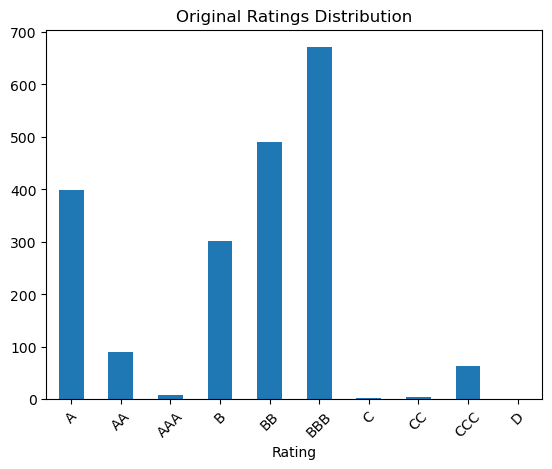

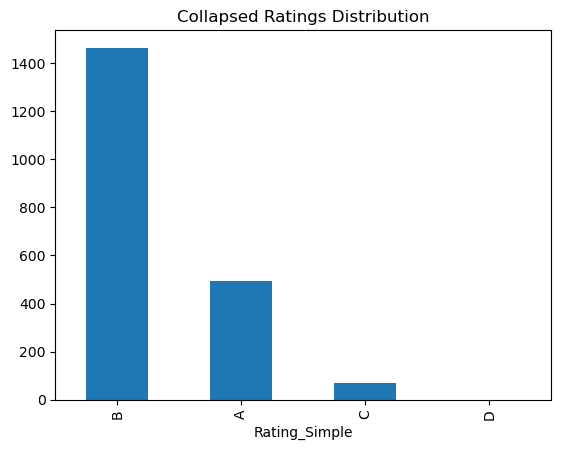

In [10]:
#2
import matplotlib.pyplot as plt
df['Rating'].value_counts().sort_index().plot(kind='bar')
plt.title("Original Ratings Distribution")
plt.xticks(rotation=45)
plt.show()

def simplify_rating(r):
    if r in ['AAA', 'AA', 'A']:
        return 'A'
    elif r in ['BBB', 'BB', 'B']:
        return 'B'
    elif r in ['CCC', 'CC', 'C']:
        return 'C'
    elif r == 'D':
        return 'D'
    else:
        return None

df['Rating_Simple'] = df['Rating'].apply(simplify_rating)

df = df.dropna(subset=['Rating_Simple'])
df['Rating_Simple'].value_counts().plot(kind='bar')
plt.title("Collapsed Ratings Distribution")
plt.show()

In [11]:
# Drops unnecessary columns
X = df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating Agency Name', 'Rating_Simple'])

# One-hot encode 'Sector'
X = pd.get_dummies(X, columns=['Sector'], drop_first=True)
y = df['Rating_Simple']

Accuracy: 0.6823


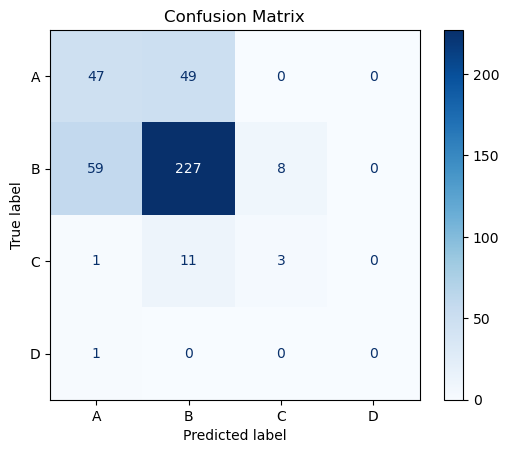

In [15]:
#4
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay

# splitting it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
# training the decision tree
clf = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf.fit(X_train, y_train)

y_pred = clf.predict(X_test) #predict
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")
# Confusion matrix
cm = confusion_matrix(y_test, y_pred, labels=['A', 'B', 'C', 'D'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['A', 'B', 'C', 'D'])
disp.plot(cmap='Blues')
plt.title("Confusion Matrix")
plt.show()


The decision tree model achieved an accuracy of about 68%, which means it was correct in a little over two-thirds of the cases. It did a good job predicting bonds with a B rating as it got 227 correct, but it struggled more with A and C ratings. For example, almost half of the A-rated bonds were predicted as B, and most C-rated ones were also misclassified as B. The model couldn't predict D-rated bonds correctly at all, likely because there were very few of them. Overall, the model is decent at predicting the most common rating (B), but it has trouble with the less common ones, which might be due to class imbalance in the dataset.

In [16]:
#5 
X_with_agency = df.drop(columns=['Rating', 'Date', 'Name', 'Symbol', 'Rating_Simple'])
X_with_agency = pd.get_dummies(X_with_agency, columns=['Sector', 'Rating Agency Name'], drop_first=True)
y_with_agency = df['Rating_Simple']

X2_train, X2_test, y2_train, y2_test = train_test_split(X_with_agency, y_with_agency, test_size=0.2, random_state=42)
clf2 = DecisionTreeClassifier(min_samples_leaf=10, random_state=42)
clf2.fit(X2_train, y2_train)
y2_pred = clf2.predict(X2_test)

acc2 = accuracy_score(y2_test, y2_pred)
print(f"Accuracy with Rating Agency: {acc2:.4f}")

Accuracy with Rating Agency: 0.7562


**Q5.** This is a case study about detecting fraud using classification trees. The goal is to predict the `class` variable, which is 0 for non-fraud and 1 for fraud.

1. Open `./data/creditcard_fraud.csv`. Print the number of observations and variables, and look at the first few rows of data. The variables are already normalized and de-identified, and are just called things like `V8` to protect the privacy of the clients.

2. Print a table of counts for the `class` variable and make a histogram. What percentage of transactions are fraudulent?

3. Drop `Time` and make a decision tree classifier to predict fraud. Print a confusion table and compute the accuracy. This is a serious **class imbalance** problem: The minority class is so small that essentially predicting 0's for all cases will achieve an extremely high accuracy. There are over-sampling techniques to deal with this issue, but we don't have time to cover them in class.

4. Imagine that you block every transaction in the test set labelled as fraudulent. How much money is (1) saved that should be saved, (2) lost to fraud anyway, (3) withheld in error from customers? Does implementing this anti-fraud system seem like a good idea, or not? Why?

5. Instead of predicting fraud, predict loss: Multiple the `Class` variable times the `Amount` variable, and call it `Loss`. Predict it using a decision tree regressor (making sure to drop Class, Time, and Loss from the features/covariates/predictors). What $R^2$ and RMSE do you get? Make a scatterplot of the predicted values on the test group versus the actual test values. Do you notice any interesting patterns? How could you use this algorithm to decide which transactions to block, and why?


**Q6.** Show that any decision tree is equivalent to a linear regression on a set of dummy variables that represent the optimal splits in the tree. 

Hint: You can think of CART as partitioning the feature space into a set of sets $\{S_1, S_2, ..., S_K\}$, and then predicting the average for all of the observations in each set $S_k$, $m_k$:
$$
\hat{y}(x) = \sum_{k=1}^K \mathbb{I}\{ x \text{ is in } S_k \} m_k
$$
where $\mathbb{I} \{ P(x,k)\}$ takes the value 1 if the proposition $P(x,k)$ is true and 0 otherwise. Now, doesn't that look like least-squares regression on a set of dummy/one-hot-encoded variables?

Conversely, can any linear regression be represented by a tree?